In [1]:
import pandas as pd
import numpy as np

# Chargement du dataset
df = pd.read_csv("data/raw/heart_disease.csv")

# Dimensions du dataset
print("Dimensions :", df.shape)

# Aperçu des premières lignes
display(df.head())

# Noms des colonnes
print("\nColonnes :")
print(df.columns.tolist())

Dimensions : (5000, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,2,107,196.0,1.0,0.0,159.0,0.0,1.8,2.0,0.0,?,0
1,66,1,2,112,240.0,?,0.0,148.0,0.0,0.7,2.0,0.0,?,0
2,60,0,2,123,209.0,0.0,0.0,114.0,0.0,1.1,2.0,1.0,3.0,1
3,49,0,3,105,167.0,0.0,0.0,142.0,0.0,0.1,1.0,1.0,3.0,0
4,49,1,2,114,261.0,0.0,0.0,188.0,1.0,0.1,3.0,0.0,7.0,1



Colonnes :
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [2]:
# Types des variables
print("Types des variables :")
display(df.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
display(df.isna().sum())

# Statistiques descriptives
print("\nStatistiques descriptives :")
display(df.describe(include="all").T)

Types des variables :


age           int64
sex           int64
cp            int64
trestbps      int64
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
num           int64
dtype: object


Valeurs manquantes :


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,5000.0,NaN,NaN,NaN,52.4326,14.464595,28.0,40.0,52.0,65.0,77.0
sex,5000.0,NaN,NaN,NaN,0.7342,0.441802,0.0,0.0,1.0,1.0,1.0
cp,5000.0,NaN,NaN,NaN,2.7038,1.028337,1.0,2.0,3.0,4.0,4.0
trestbps,5000.0,NaN,NaN,NaN,119.9296,16.476837,90.0,108.0,120.0,131.0,178.0
chol,5000,214,?,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fbs,5000,3,0.0,4075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,5000,4,0.0,3878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalach,5000,115,150.0,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exang,5000,3,0.0,3434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldpeak,5000.0,NaN,NaN,NaN,0.9606,0.706971,0.0,0.4,0.9,1.4,5.0


In [3]:
# Rechargement du dataset en considérant "?" comme une valeur manquante
df = pd.read_csv(
    "data/raw/heart_disease.csv",
    na_values="?"
)

print("Dimensions :", df.shape)

display(df.head())

print("\nValeurs manquantes :")
display(df.isna().sum())

print("\nTypes des variables :")
display(df.dtypes)

Dimensions : (5000, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,2,107,196.0,1.0,0.0,159.0,0.0,1.8,2.0,0.0,NaN,0
1,66,1,2,112,240.0,NaN,0.0,148.0,0.0,0.7,2.0,0.0,NaN,0
2,60,0,2,123,209.0,0.0,0.0,114.0,0.0,1.1,2.0,1.0,3.0,1
3,49,0,3,105,167.0,0.0,0.0,142.0,0.0,0.1,1.0,1.0,3.0,0
4,49,1,2,114,261.0,0.0,0.0,188.0,1.0,0.1,3.0,0.0,7.0,1



Valeurs manquantes :


age           0
sex           0
cp            0
trestbps      0
chol        131
fbs          75
restecg      52
thalach      81
exang        20
oldpeak       0
slope       633
ca          856
thal        594
num           0
dtype: int64


Types des variables :


age           int64
sex           int64
cp            int64
trestbps      int64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

In [4]:
# Nombre et pourcentage de valeurs manquantes
missing = pd.DataFrame({
    "Nombre_manquant": df.isna().sum(),
    "Pourcentage_manquant": df.isna().mean() * 100
})

missing = missing[missing["Nombre_manquant"] > 0].sort_values(
    "Pourcentage_manquant",
    ascending=False
)

display(missing)

,Nombre_manquant,Pourcentage_manquant
ca,856,17.12
slope,633,12.66
thal,594,11.88
chol,131,2.62
thalach,81,1.62
fbs,75,1.50
restecg,52,1.04
exang,20,0.40


In [5]:
print("Répartition de la variable cible 'num' :")

display(df["num"].value_counts())

print("\nPourcentages :")

display(
    df["num"].value_counts(normalize=True).mul(100).round(2)
)

Répartition de la variable cible 'num' :


num
0    2719
1    2281
Name: count, dtype: int64


Pourcentages :


num
0    54.38
1    45.62
Name: proportion, dtype: float64

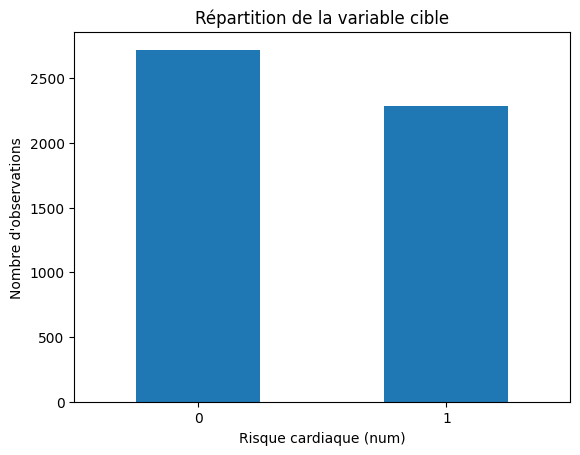

In [6]:
import matplotlib.pyplot as plt

# Répartition de la variable cible
df["num"].value_counts().sort_index().plot(kind="bar")

plt.title("Répartition de la variable cible")
plt.xlabel("Risque cardiaque (num)")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

In [7]:
# Statistiques descriptives des variables numériques
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,5000.0,52.432600,14.464595,28.0,40.0,52.0,65.0,77.0
sex,5000.0,0.734200,0.441802,0.0,0.0,1.0,1.0,1.0
cp,5000.0,2.703800,1.028337,1.0,2.0,3.0,4.0,4.0
trestbps,5000.0,119.929600,16.476837,90.0,108.0,120.0,131.0,178.0
chol,4869.0,219.210516,40.292881,120.0,192.0,220.0,246.0,344.0
fbs,4925.0,0.172589,0.377930,0.0,0.0,0.0,0.0,1.0
restecg,4948.0,0.233428,0.461887,0.0,0.0,0.0,0.0,2.0
thalach,4919.0,150.453344,19.434727,81.0,137.0,150.0,164.0,210.0
exang,4980.0,0.310442,0.462721,0.0,0.0,0.0,1.0,1.0
oldpeak,5000.0,0.960600,0.706971,0.0,0.4,0.9,1.4,5.0


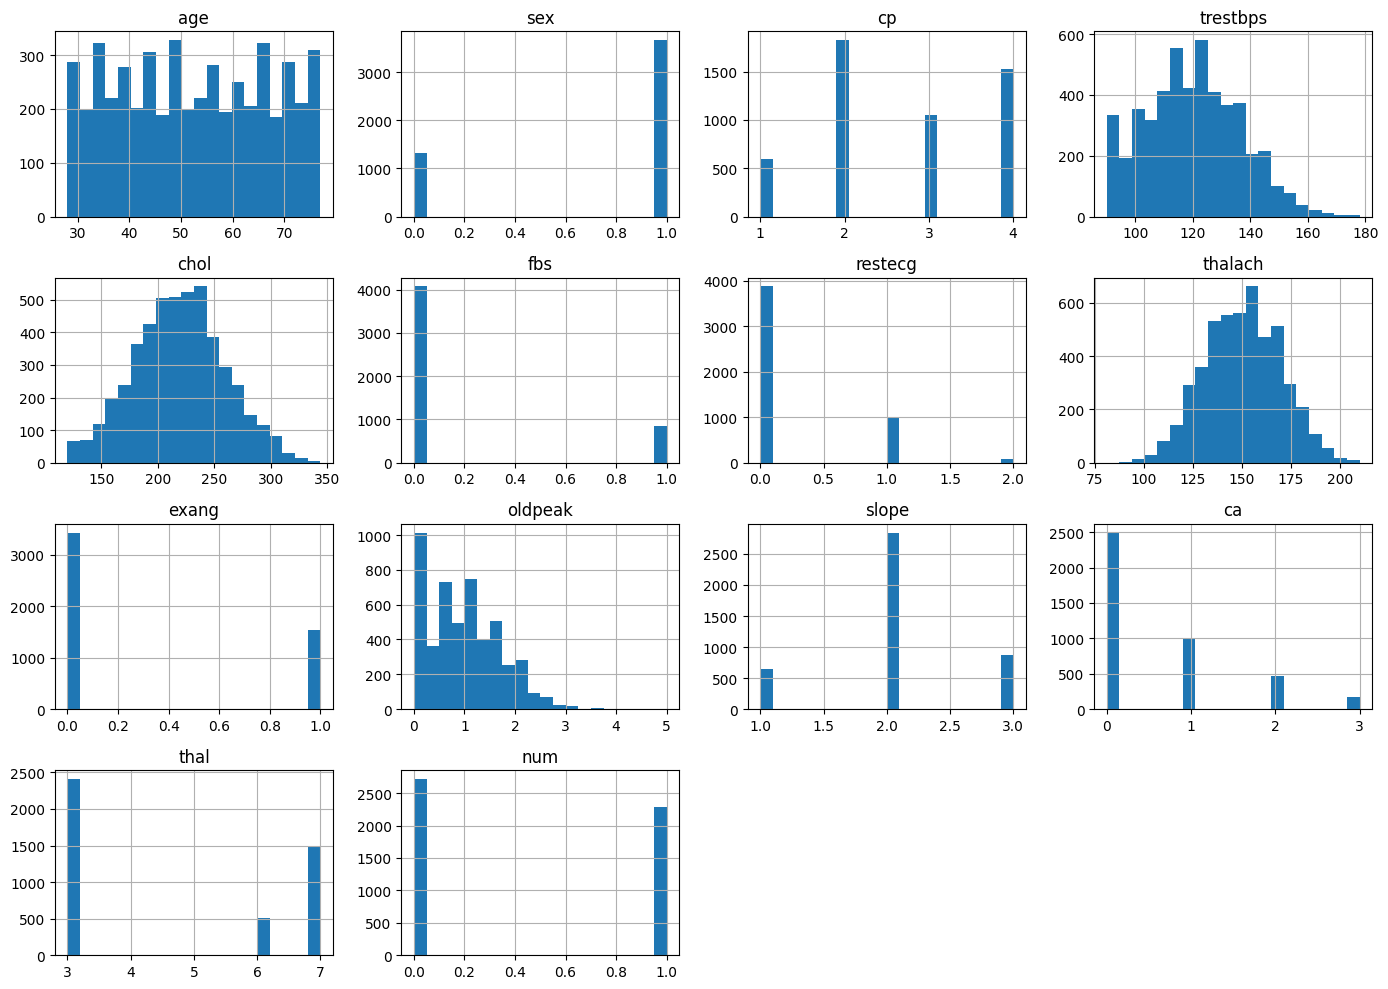

In [8]:
# Histogrammes des variables
df.hist(figsize=(14, 10), bins=20)

plt.tight_layout()
plt.show()

In [9]:
# Nombre de modalités pour chaque variable
for col in df.columns:
    print(f"{col}: {df[col].nunique(dropna=True)} modalités")

age: 50 modalités
sex: 2 modalités
cp: 4 modalités
trestbps: 85 modalités
chol: 213 modalités
fbs: 2 modalités
restecg: 3 modalités
thalach: 114 modalités
exang: 2 modalités
oldpeak: 39 modalités
slope: 3 modalités
ca: 4 modalités
thal: 3 modalités
num: 2 modalités


In [10]:
# Valeurs présentes dans les variables à faible nombre de modalités
for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "num"]:
    print(f"\n--- {col} ---")
    print(sorted(df[col].dropna().unique()))


--- sex ---
[np.int64(0), np.int64(1)]

--- cp ---
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- fbs ---
[np.float64(0.0), np.float64(1.0)]

--- restecg ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0)]

--- exang ---
[np.float64(0.0), np.float64(1.0)]

--- slope ---
[np.float64(1.0), np.float64(2.0), np.float64(3.0)]

--- ca ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

--- thal ---
[np.float64(3.0), np.float64(6.0), np.float64(7.0)]

--- num ---
[np.int64(0), np.int64(1)]


In [11]:
# Moyennes des variables numériques selon la cible
display(
    df.groupby("num").mean(numeric_only=True).T
)

num,0,1
age,46.840750,59.098203
sex,0.691798,0.784744
cp,2.590658,2.838667
trestbps,115.853623,124.788251
chol,209.370664,230.981055
fbs,0.134873,0.217760
restecg,0.238467,0.227434
thalach,155.319538,144.619133
exang,0.178229,0.468282
oldpeak,0.749209,1.212582


In [12]:
# Répartition des modalités selon la cible
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    display(
        pd.crosstab(
            df[col],
            df["num"],
            normalize="index"
        ).round(3)
    )


===== sex =====


num,0,1
sex,,
0,0.631,0.369
1,0.512,0.488



===== cp =====


num,0,1
cp,,
1,0.605,0.395
2,0.596,0.404
3,0.554,0.446
4,0.452,0.548



===== fbs =====


num,0,1
fbs,,
0.0,0.570,0.430
1.0,0.426,0.574



===== restecg =====


num,0,1
restecg,,
0.0,0.542,0.458
1.0,0.539,0.461
2.0,0.647,0.353



===== exang =====


num,0,1
exang,,
0.0,0.649,0.351
1.0,0.312,0.688



===== slope =====


num,0,1
slope,,
1.0,0.560,0.440
2.0,0.538,0.462
3.0,0.548,0.452



===== ca =====


num,0,1
ca,,
0.0,0.574,0.426
1.0,0.474,0.526
2.0,0.514,0.486
3.0,0.509,0.491



===== thal =====


num,0,1
thal,,
3.0,0.566,0.434
6.0,0.606,0.394
7.0,0.490,0.510


In [13]:
# Séparation des variables explicatives et de la cible

X = df.drop(columns="num")
y = df["num"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

display(X.head())
display(y.head())

Dimensions de X : (5000, 13)
Dimensions de y : (5000,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,32,1,2,107,196.0,1.0,0.0,159.0,0.0,1.8,2.0,0.0,NaN
1,66,1,2,112,240.0,NaN,0.0,148.0,0.0,0.7,2.0,0.0,NaN
2,60,0,2,123,209.0,0.0,0.0,114.0,0.0,1.1,2.0,1.0,3.0
3,49,0,3,105,167.0,0.0,0.0,142.0,0.0,0.1,1.0,1.0,3.0
4,49,1,2,114,261.0,0.0,0.0,188.0,1.0,0.1,3.0,0.0,7.0


0    0
1    0
2    1
3    0
4    1
Name: num, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nRépartition de la cible dans le train :")
print(y_train.value_counts(normalize=True).round(3))

print("\nRépartition de la cible dans le test :")
print(y_test.value_counts(normalize=True).round(3))

X_train : (4000, 13)
X_test  : (1000, 13)
y_train : (4000,)
y_test  : (1000,)

Répartition de la cible dans le train :
num
0    0.544
1    0.456
Name: proportion, dtype: float64

Répartition de la cible dans le test :
num
0    0.544
1    0.456
Name: proportion, dtype: float64


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Variables numériques
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Variables catégorielles
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Prétraitement des variables numériques :
# remplacement des valeurs manquantes par la médiane
# puis standardisation
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Prétraitement des variables catégorielles :
# remplacement des valeurs manquantes par la modalité la plus fréquente
# puis encodage One-Hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Préprocesseur global
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


In [17]:
# Prédictions
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Premières prédictions :", y_pred[:10])
print("Premières probabilités :", y_proba[:10])

Premières prédictions : [1 1 0 1 0 1 0 1 0 0]
Premières probabilités : [0.95923768 0.92243126 0.11080539 0.59510869 0.25049611 0.88350246
 0.12034977 0.71177509 0.07473601 0.30645809]


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Résultats - Régression logistique")
print("-----------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Résultats - Régression logistique
-----------------------------------
Accuracy  : 0.7160
Precision : 0.6937
Recall    : 0.6754
F1-score  : 0.6844
ROC-AUC   : 0.7915


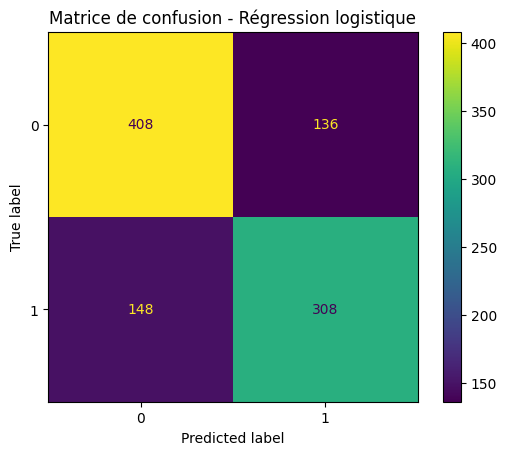

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Matrice de confusion - Régression logistique")
plt.show()

Résultats - Random Forest
-----------------------------------
Accuracy  : 0.7060
Precision : 0.6761
Recall    : 0.6820
F1-score  : 0.6790
ROC-AUC   : 0.7647


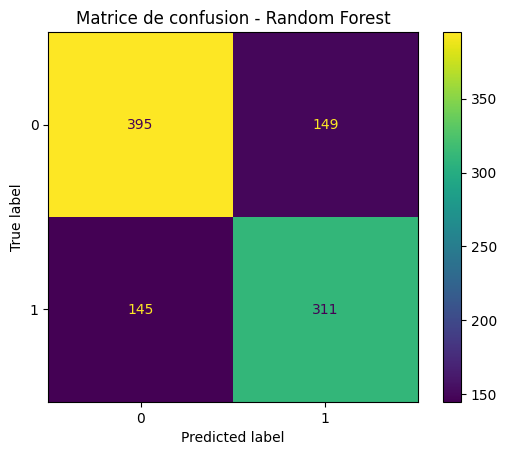

In [20]:
# ============================================
# Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Création du pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calcul des métriques
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

# Affichage des résultats
print("Résultats - Random Forest")
print("-----------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Matrice de confusion - Random Forest")
plt.show()

In [21]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [ ]:
Conclusion — Random Forest

Le Random Forest obtient une accuracy de 70,6 % et un ROC-AUC de 0,765 sur l'échantillon de test. Ses performances sont légèrement inférieures à celles de la régression logistique sur la plupart
des métriques. Cependant, son recall est légèrement supérieur (68,20 % contre 67,54 %), ce qui signifie qu'il détecte légèrement plus de cas de classe 1. À ce stade, la régression logistique reste
le modèle le plus performant, mais la comparaison sera poursuivie avec le Gradient Boosting.

Résultats - Gradient Boosting
-----------------------------------
Accuracy  : 0.7150
Precision : 0.6863
Recall    : 0.6908
F1-score  : 0.6885
ROC-AUC   : 0.7792


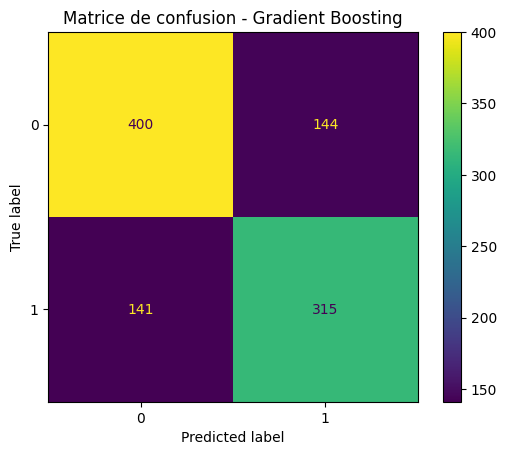

In [23]:
# ============================================
# Gradient Boosting
# ============================================

from sklearn.ensemble import GradientBoostingClassifier

# Création du pipeline
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Entraînement
gb_model.fit(X_train, y_train)

# Prédictions
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Calcul des métriques
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

# Affichage des résultats
print("Résultats - Gradient Boosting")
print("-----------------------------------")
print(f"Accuracy  : {accuracy_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1-score  : {f1_gb:.4f}")
print(f"ROC-AUC   : {roc_auc_gb:.4f}")

# Matrice de confusion
cm_gb = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Matrice de confusion - Gradient Boosting")
plt.show()

In [24]:
# ============================================
# Comparaison des 3 modèles
# ============================================

results = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_rf,
        recall_gb
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_rf,
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_rf,
        roc_auc_gb
    ]
})

results = results.set_index("Modèle")

results.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modèle,,,,,
Régression logistique,0.716,0.6937,0.6754,0.6844,0.7915
Random Forest,0.706,0.6761,0.6820,0.6790,0.7647
Gradient Boosting,0.715,0.6863,0.6908,0.6885,0.7792


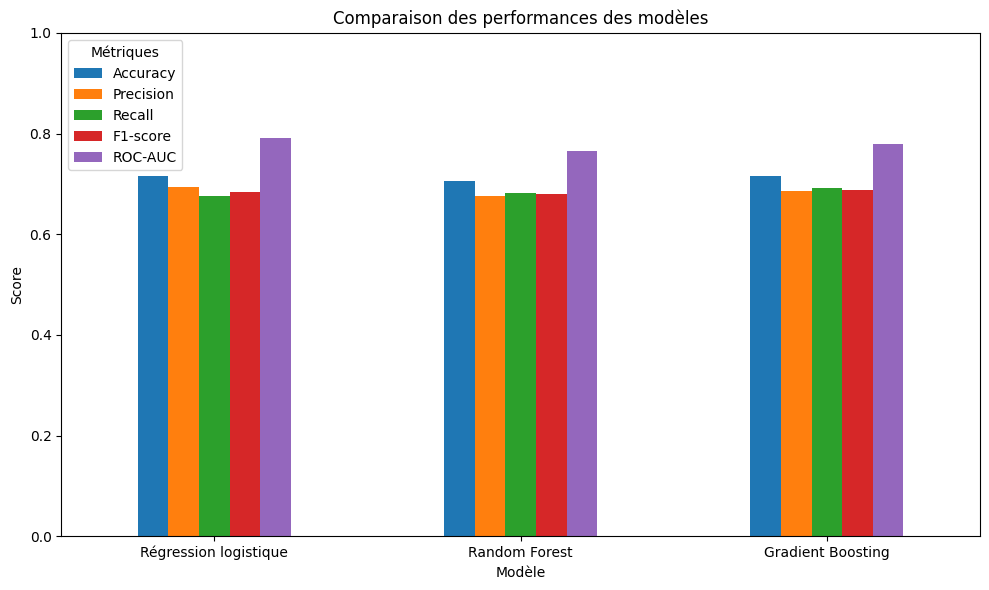

In [25]:
# Graphique de comparaison des performances

results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xlabel("Modèle")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métriques")
plt.tight_layout()
plt.show()

In [27]:
# ============================================
# Validation croisée - comparaison des modèles
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

# Recréation du modèle de régression logistique
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Validation croisée stratifiée en 5 folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modèles à comparer
models = {
    "Régression logistique": logreg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

# Métriques utilisées
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

# Calcul de la validation croisée
cv_results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Modèle": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "Recall": scores["test_Recall"].mean(),
        "F1-score": scores["test_F1-score"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean()
    })

# Création du tableau
cv_results = pd.DataFrame(cv_results)

print("Résultats de la validation croisée (5 folds)")
print("-----------------------------------------------")

display(cv_results.round(4))

Résultats de la validation croisée (5 folds)
-----------------------------------------------


,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Régression logistique,0.7202,0.7024,0.6723,0.6867,0.7867
1,Random Forest,0.7032,0.6834,0.6537,0.6679,0.7658
2,Gradient Boosting,0.7133,0.6912,0.6718,0.6812,0.7755


In [28]:
logreg_model = Pipeline(...)

In [29]:
"Régression logistique": logreg_model

SyntaxError: illegal target for annotation (3920075774.py, line 1)

In [30]:
# ============================================
# Optimisation de la régression logistique
# ============================================

from sklearn.model_selection import GridSearchCV

# Modèle de base
logreg_optim = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Hyperparamètres à tester
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

# Recherche des meilleurs paramètres
grid_search = GridSearchCV(
    estimator=logreg_optim,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# Entraînement
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur F1-score moyen en validation croisée :")
print(f"{grid_search.best_score_:.4f}")

Meilleurs paramètres :
{'classifier__C': 0.1, 'classifier__solver': 'liblinear'}

Meilleur F1-score moyen en validation croisée :
0.6877


Résultats - Régression logistique optimisée
-----------------------------------------------
Accuracy  : 0.7190
Precision : 0.6966
Recall    : 0.6798
F1-score  : 0.6881
ROC-AUC   : 0.7910


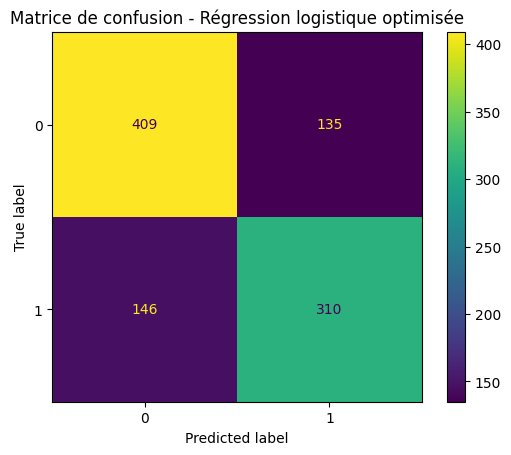

In [31]:
# ============================================
# Évaluation finale du modèle optimisé
# ============================================

# Récupération du meilleur modèle
best_logreg = grid_search.best_estimator_

# Prédictions sur le jeu de test
y_pred_best = best_logreg.predict(X_test)
y_proba_best = best_logreg.predict_proba(X_test)[:, 1]

# Calcul des métriques
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_proba_best)

# Affichage
print("Résultats - Régression logistique optimisée")
print("-----------------------------------------------")
print(f"Accuracy  : {accuracy_best:.4f}")
print(f"Precision : {precision_best:.4f}")
print(f"Recall    : {recall_best:.4f}")
print(f"F1-score  : {f1_best:.4f}")
print(f"ROC-AUC   : {roc_auc_best:.4f}")

# Matrice de confusion
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Matrice de confusion - Régression logistique optimisée")
plt.show()

In [ ]:
Conclusion — Optimisation

L'optimisation de la régression logistique par GridSearchCV a permis d'identifier les paramètres C = 0.1 et solver = liblinear. Le F1-score moyen obtenu en validation croisée passe de 0.6867 à 0.6877.
Sur le jeu de test, le modèle optimisé obtient une accuracy de 71,9 % et un F1-score de 68,81 %. L'amélioration reste limitée, mais le modèle optimisé présente de meilleures performances globales que
le modèle initial.

In [32]:
# ============================================
# Interprétation de la régression logistique
# ============================================

# Récupération du préprocesseur et du modèle
preprocessor_fitted = best_logreg.named_steps["preprocessor"]
classifier = best_logreg.named_steps["classifier"]

# Récupération des noms des variables après transformation
feature_names = preprocessor_fitted.get_feature_names_out()

# Récupération des coefficients
coefficients = classifier.coef_[0]

# Création d'un tableau
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients
})

# Valeur absolue pour mesurer l'importance
coef_df["Importance"] = coef_df["Coefficient"].abs()

# Trier par importance
coef_df = coef_df.sort_values(
    by="Importance",
    ascending=False
)

display(coef_df.round(4))

,Variable,Coefficient,Importance
0,num__age,0.6194,0.6194
16,cat__exang_0.0,-0.3347,0.3347
10,cat__cp_4.0,0.3253,0.3253
17,cat__exang_1.0,0.3104,0.3104
5,cat__sex_0.0,-0.2665,0.2665
27,cat__thal_7.0,0.2659,0.2659
4,num__oldpeak,0.2616,0.2616
21,cat__ca_0.0,-0.2578,0.2578
6,cat__sex_1.0,0.2423,0.2423
7,cat__cp_1.0,-0.2199,0.2199


In [ ]:
Conclusion — Interprétation du modèle

L'analyse des coefficients de la régression logistique montre que plusieurs variables contribuent fortement aux prédictions du modèle. L'âge présente notamment le coefficient le plus important en
valeur absolue (+0,6194), suivi de plusieurs modalités des variables exang, cp, sex et thal, ainsi que de la variable oldpeak. À l'inverse, certaines modalités présentent une contribution beaucoup
plus faible. Ces coefficients permettent d'interpréter les facteurs utilisés par le modèle pour différencier les deux classes, sans toutefois permettre d'établir une relation causale.

In [33]:
# ============================================
# Analyse des erreurs
# ============================================

# Copie du jeu de test avec les prédictions
error_analysis = X_test.copy()

error_analysis["y_true"] = y_test
error_analysis["y_pred"] = y_pred_best
error_analysis["proba_classe_1"] = y_proba_best

# Identifier les erreurs
false_positives = error_analysis[
    (error_analysis["y_true"] == 0) &
    (error_analysis["y_pred"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["y_true"] == 1) &
    (error_analysis["y_pred"] == 0)
]

print("Analyse des erreurs")
print("-------------------")
print(f"Faux positifs : {len(false_positives)}")
print(f"Faux négatifs : {len(false_negatives)}")
print(f"Total erreurs : {len(error_analysis[error_analysis['y_true'] != error_analysis['y_pred']])}")

print("\nQuelques faux positifs :")
display(false_positives.head())

print("\nQuelques faux négatifs :")
display(false_negatives.head())

Analyse des erreurs
-------------------
Faux positifs : 135
Faux négatifs : 146
Total erreurs : 281

Quelques faux positifs :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,proba_classe_1
2239,72,1,4,127,327.0,0.0,1.0,157.0,1.0,3.2,NaN,0.0,7.0,0,1,0.957108
3629,69,1,2,111,236.0,0.0,1.0,121.0,0.0,0.9,2.0,0.0,7.0,0,1,0.614838
1225,76,0,2,147,242.0,1.0,0.0,116.0,0.0,1.3,2.0,0.0,NaN,0,1,0.609859
858,61,1,4,124,206.0,0.0,0.0,142.0,1.0,0.5,2.0,2.0,3.0,0,1,0.707435
2481,71,1,3,140,166.0,0.0,0.0,122.0,0.0,1.3,2.0,2.0,3.0,0,1,0.652924



Quelques faux négatifs :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,proba_classe_1
4544,50,0,3,121,207.0,0.0,0.0,142.0,0.0,1.5,1.0,0.0,3.0,1,0,0.258036
2791,35,1,2,111,199.0,0.0,0.0,154.0,0.0,0.1,2.0,NaN,3.0,1,0,0.123471
2134,50,1,3,106,216.0,0.0,0.0,140.0,1.0,0.9,3.0,0.0,3.0,1,0,0.470284
3790,33,1,3,119,253.0,0.0,0.0,174.0,0.0,0.0,2.0,3.0,7.0,1,0,0.276606
2564,49,0,2,139,168.0,1.0,0.0,166.0,0.0,2.2,NaN,NaN,3.0,1,0,0.295339


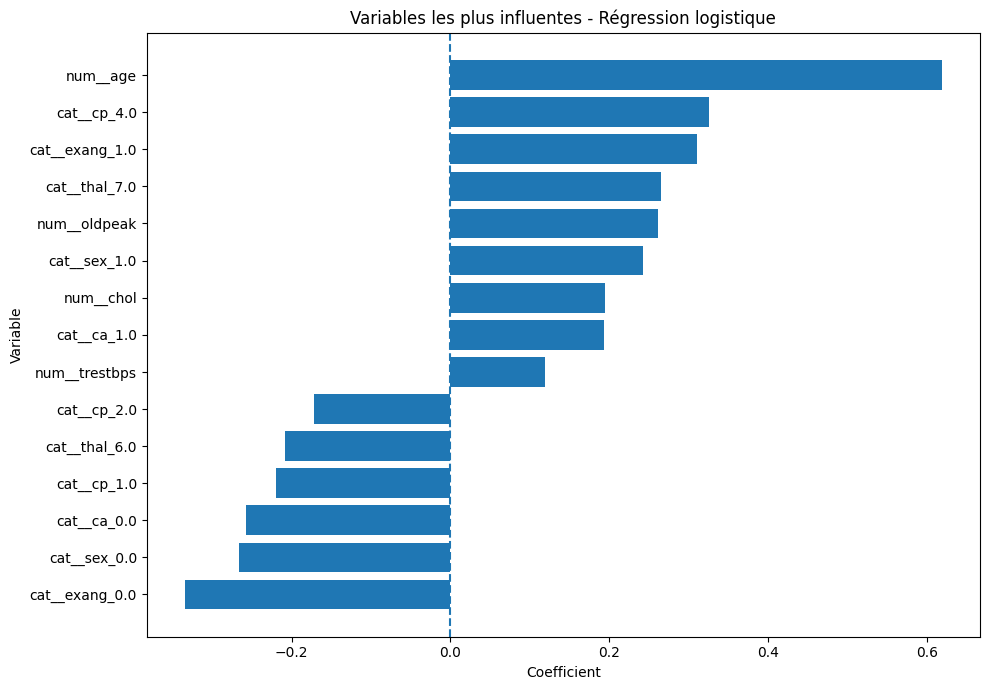

In [34]:
# ============================================
# Visualisation des coefficients
# ============================================

top_n = 15

coef_plot = coef_df.head(top_n).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coef_plot["Variable"],
    coef_plot["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Variables les plus influentes - Régression logistique")
plt.xlabel("Coefficient")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()